In [172]:
import numpy as np

In [173]:
data = [
    [12.0, 1.5, 1, 'Wine'],
    [5.0, 2.0, 0, 'Beer'],
    [40.0, 0.0, 1, 'Whiskey'],
    [13.5, 1.2, 1, 'Wine'],
    [4.5, 1.8, 0, 'Beer'],
    [38.0, 0.1, 1, 'Whiskey'],
    [11.5, 1.7, 1, 'Wine'],
    [5.5, 2.3, 0, 'Beer']
]

In [174]:
for i in data:
    label = i[3]
    if label == 'Wine':
        i[3] = 0
    elif label == 'Beer':
        i[3] = 1
    else:
        i[3] = 2
X_train = np.array([i[:3] for i in data], dtype=np.float32)
y_train = np.array([i[3] for i in data])

In [175]:
def gini(y):
    y = np.array(y)
    n = len(y)
    if n==0:
        return 0.0
    classes,counts = np.unique(y,return_counts=True)
    prob = counts/n
    return (1-np.sum(prob**2))

def entropy(y):
    y = np.array(y)
    n = len(y)
    if n==0:
        return 0.0
    classes,counts = np.unique(y,return_counts=True)
    prob = counts/n
    return -np.sum(prob*np.log2(prob))
# entropy is more costlier to calculate than gini
# both give a measure of uncertainty of a split, if at a level that uncertainty is 0 it means we have enough info to classify

In [176]:
def split_finder(x,y,criterion="gini"):
    if criterion == "gini":
        split_func = gini
    else:
        split_func = entropy
    n_samples,n_features = x.shape

    best_feature = None
    best_thresh = None
    best_gain = 0
    # calculate uncertainty at parent level
    parent = split_func(y)
    classes = np.unique(y)
    n_classes = len(classes)
    n = len(y)
    # iterate over all features -> get the unique features as candidates for thresholds -> calculate the info gain / loss in uncertainty for each threshold
    # select best feature and its threshold value for splitting
    for feature in range(n_features):
        thresholds = np.unique(x[:,feature])
        for thresh in thresholds:
            left = x[:,feature] <= thresh
            right = ~left

            #skip if split is empty
            if not np.any(left) or not np.any(right):
                continue
            n_left,n_right = np.sum(left),np.sum(right)

            child = (n_left/n) * split_func(y[left]) + (n_right/n) * split_func(y[right])
            gain = parent - child
            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_thresh = thresh

    return best_feature,best_thresh,best_gain


In [177]:
class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None,info_gain=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # only set if leaf
        self.info_gain = info_gain

class DecisionTree:
    def __init__(self, max_depth=10, min_samples=1, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.criterion = criterion
        self.root = None

    def majority(self, y):
        # returns the class with max count of a particular label at a node
        counts = np.bincount(np.array(y))
        return int(np.argmax(counts))

    def build(self, X, y, depth):
        # stopping conditions
        if depth >= self.max_depth or len(y) <= self.min_samples or len(set(y)) == 1:
            return Node(value=self.majority(y))

        feat, thresh,gain = split_finder(X, y, self.criterion)
        if feat is None:
            return Node(value=self.majority(y))
        # masks for splitting
        left = X[:,feat] <= thresh 
        right = ~left
        left_child = self.build(X[left],y[left],depth+1)
        right_child = self.build(X[right],y[right],depth+1)

        return Node(feature_index=feat, threshold=thresh, left=left_child, right=right_child,info_gain=gain)

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        # build the tree from depth=0
        self.root = self.build(X,y,0)

    def traverse(self, node, x):
        # at leaf, nodes value is set to not none
        if node.value is not None:
            return node.value
        # else keep traversing
        if x[node.feature_index] <= node.threshold:
            return self.traverse(node.left, x)
        else:
            return self.traverse(node.right, x)

    def predict_one(self, x):
        return self.traverse(self.root, x)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

In [178]:
def accuracy(y_pred, y_true):
    return (np.sum(y_true == y_pred) / len(y_true)) * 100

def train_test_split(x, y, ratio=0.5):
    n = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    split = int(n*ratio)
    train_idx = indices[:split]
    test_idx = indices[split:]
    return x[train_idx], x[test_idx], y[train_idx], y[test_idx]

In [179]:
# normalisation functions
# min max normalizes for all features to scale down and fit in [0,1]
# thresholds to avoid division by 0
def minmax(x):
    x = np.array(x)
    min,max = x.min(axis=0),x.max(axis=0)
    return (x-min)/(max-min+1e-8)
# normalizes cause each set of features values to have 0 mean nd std 1
def zscore(X):
    X = np.array(X, dtype=np.float32)
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    return (X - mean)/(std + 1e-8)
X_train_normalised = minmax(X_train)

In [180]:
test_data = [
    [6.0, 2.1, 0],   # Expected: Beer
    [39.0, 0.05, 1], # Expected: Whiskey
    [13.0, 1.3, 1]   # Expected: Wine
]
test_data_normalised = minmax(test_data)
model = DecisionTree(max_depth=15, criterion='gini')
model.fit(X_train_normalised, y_train)
y_pred = model.predict(test_data_normalised)
print("Predictions (with normalised data) :", y_pred)
labels = ['Wine', 'Beer', 'Whiskey']
print([labels[i] for i in y_pred])

Predictions (with normalised data) : [1 2 0]
['Beer', 'Whiskey', 'Wine']


In [181]:
model.fit(X_train,y_train)
y_pred = model.predict(test_data)
print("Predictions (with normal data) :", y_pred)
print([labels[i] for i in y_pred])
 

Predictions (with normal data) : [0 2 0]
['Wine', 'Whiskey', 'Wine']


In [182]:
feature_names = ['Alcohol (%)', 'Sugar (g/L)', 'Color']

def print_tree(node, depth=0):
    indent = "    " * depth
    if node.value is not None:
        print(f"{indent}-> Predict: {labels[node.value]}")
        return
    print(f"{indent}if {feature_names[node.feature_index]} <= {node.threshold}: (Info gain: {node.info_gain})")
    print_tree(node.left, depth+1)
    print(f"{indent}else:")
    print_tree(node.right, depth+1)

# NOT NORMALISED
full_model = DecisionTree(max_depth=15, criterion='gini')
full_model.fit(X_train, y_train)
print("Not normalised tree")
print()
print_tree(full_model.root)

Not normalised tree

if Alcohol (%) <= 5.5: (Info gain: 0.35625)
    -> Predict: Beer
else:
    if Alcohol (%) <= 13.5: (Info gain: 0.48)
        -> Predict: Wine
    else:
        -> Predict: Whiskey


In [183]:
#NORMALISED SPLITS
full_model.fit(X_train_normalised, y_train)
print("Normalised tree")
print()
print_tree(full_model.root)

Normalised tree

if Alcohol (%) <= 0.028169013559818268: (Info gain: 0.35625)
    -> Predict: Beer
else:
    if Alcohol (%) <= 0.2535211145877838: (Info gain: 0.48)
        -> Predict: Wine
    else:
        -> Predict: Whiskey


Normalisation helps because the range of alcohold is very large compared to sugar nd color
this leads to very hard/coarse splits, info gain only depends on class distribtuion not feature values thats why
they have identical info gain, but features thresholds change which nullifies the effect of irregular ranges 

In [ ]:
# With train test split and accuracy
X_train_np = np.array(X_train_normalised)
y_train_np = np.array(y_train)

#since this is a very small dataset, splitting on which isnt very meaningful
# with 8 samples -> 80-20 split -> 6 train, 2test which makes accuracy noisy
X_tr, X_te, y_tr, y_te = train_test_split(X_train_np, y_train_np, 0.9)
model.fit(list(X_tr),list(y_tr))
y_pred2 = model.predict(list(X_te))
print("Accuracy : ", accuracy(y_pred2, y_te))

Accuracy :  100.0


In [185]:
# Gini vs Entropy
for crit in ['gini', 'entropy']:
    dt = DecisionTree(max_depth=10, criterion=crit)
    dt.fit(list(X_tr),list(y_tr))
    preds = dt.predict(test_data_normalised)
    print(f"{crit}: {preds} -> {[labels[i] for i in preds]}")

gini: [1 2 0] -> ['Beer', 'Whiskey', 'Wine']
entropy: [1 2 0] -> ['Beer', 'Whiskey', 'Wine']


In [186]:
# Effect of max_depth on accuracy
for d in range(1,6):
    dt = DecisionTree(max_depth=d, criterion='gini')
    dt.fit(list(X_tr),list(y_tr))
    preds = dt.predict(X_te.tolist())
    print(f"max_depth={d} -> {accuracy(preds, y_te):.1f}%")

max_depth=1 -> 0.0%
max_depth=2 -> 100.0%
max_depth=3 -> 100.0%
max_depth=4 -> 100.0%
max_depth=5 -> 100.0%


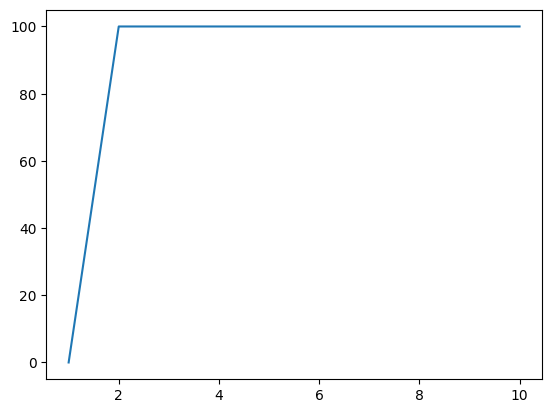

In [187]:
import matplotlib.pyplot as plt
# accuracies for different max_depth values
accuracies = []
for k in range(1, 11):
    dt = DecisionTree(max_depth=k, criterion='gini')
    dt.fit(list(X_tr), list(y_tr))
    y_pred3 = dt.predict(list(X_te))
    accuracies.append(accuracy(y_pred3, y_te))
plt.plot(range(1,11), accuracies)
plt.show()

In [188]:
for min_samp in range(1,5):
    dt = DecisionTree(max_depth=15, min_samples=min_samp, criterion='gini')
    dt.fit(list(X_tr), list(y_tr))
    preds = dt.predict(list(X_te))
    acc = accuracy(preds, y_te)
    print(f"min_samples={min_samp} -> Accuracy: {acc:.1f}%")

for min_samp in [1, 2]:
    print(f"\nmin_samples={min_samp}")
    dt = DecisionTree(max_depth=10, min_samples=min_samp, criterion='gini')
    dt.fit(X_train_normalised, y_train)
    print_tree(dt.root)

min_samples=1 -> Accuracy: 100.0%
min_samples=2 -> Accuracy: 100.0%
min_samples=3 -> Accuracy: 100.0%
min_samples=4 -> Accuracy: 0.0%

min_samples=1
if Alcohol (%) <= 0.028169013559818268: (Info gain: 0.35625)
    -> Predict: Beer
else:
    if Alcohol (%) <= 0.2535211145877838: (Info gain: 0.48)
        -> Predict: Wine
    else:
        -> Predict: Whiskey

min_samples=2
if Alcohol (%) <= 0.028169013559818268: (Info gain: 0.35625)
    -> Predict: Beer
else:
    if Alcohol (%) <= 0.2535211145877838: (Info gain: 0.48)
        -> Predict: Wine
    else:
        -> Predict: Whiskey
